# To Plot the Heatmap of Table 2 (For Classification Test Cases)

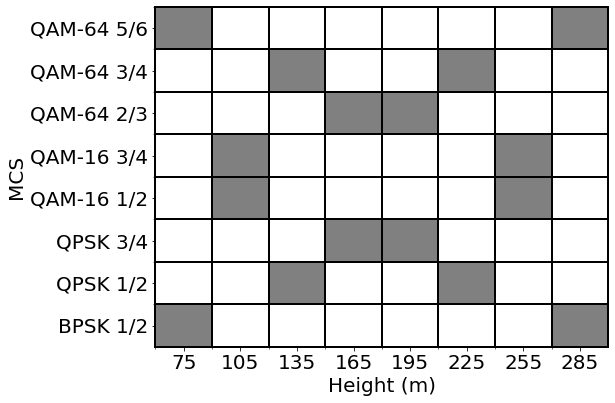

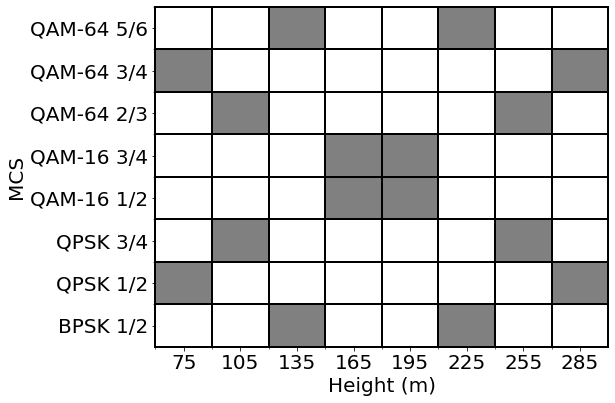

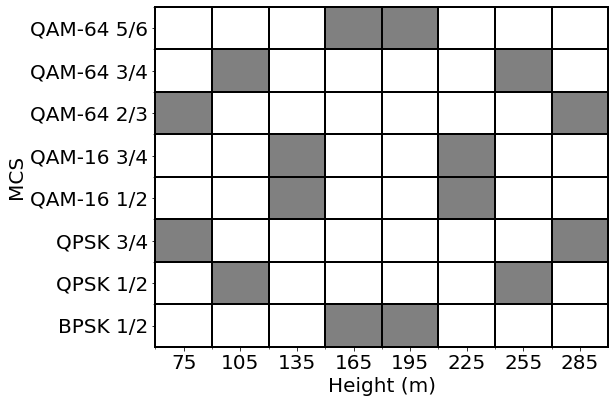

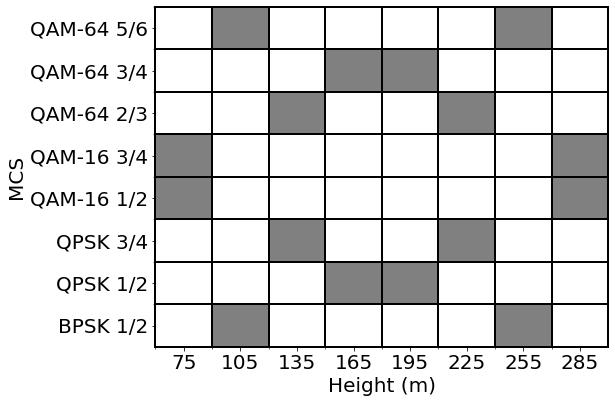

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import glob, os

""" The Lists of Parameters for Test Cases (for zip) """
test_heights = [75, 135, 195, 255, 75, 135, 195, 255, 75, 135, 195, 255, 75, 135, 195, 255, 105, 165, 225, 285, 105, 
                165, 225, 285, 105, 165, 225, 285, 105, 165, 225, 285, 75, 135, 195, 255, 75, 135, 195, 255, 75, 135, 
                195, 255, 75, 135, 195, 255, 105, 165, 225, 285, 105, 165, 225, 285, 105, 165, 225, 285, 105, 165, 225, 285]
test_bitrates = [6.5, 6.5, 6.5, 6.5, 13, 13, 13, 13, 19.5, 19.5, 19.5, 19.5, 26, 26, 26, 26, 39, 39, 39, 39, 52, 52, 52, 52, 
                 58.5, 58.5, 58.5, 58.5, 65, 65, 65, 65, 65, 65, 65, 65, 58.5, 58.5, 58.5, 58.5, 52, 52, 52, 52, 39, 39, 39, 39, 
                 26, 26, 26, 26, 19.5, 19.5, 19.5, 19.5, 13, 13, 13, 13, 6.5, 6.5, 6.5, 6.5]
test_usi = [10, 20, 66.7, 100, 20, 10, 100, 66.7, 66.7, 100, 10, 20, 100, 66.7, 20, 10, 10, 20, 66.7, 100, 20, 10, 100, 66.7, 66.7, 100, 10, 20, 100, 66.7, 20, 10, 
            10, 20, 66.7, 100, 20, 10, 100, 66.7, 66.7, 100, 10, 20, 100, 66.7, 20, 10, 10, 20, 66.7, 100, 20, 10, 100, 66.7, 66.7, 100, 10, 20, 100, 66.7, 20, 10]


test_cases = list(zip(test_bitrates, test_heights, test_usi))
heights = [75, 105, 135, 165, 195, 225, 255, 285]
bitrates = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
usis = [10, 20, 66.7, 100]
heatmap = np.zeros((8, 8, 4), dtype=int)

i = 0
for usi in usis:
    j = 0
    for height in heights:
        k = 0
        for bitrate in bitrates:
            if (bitrate, height, usi) in test_cases:
                heatmap[k, j, i] = 1
            k += 1
        j += 1
    i += 1

mcs = ["BPSK 1/2", "QPSK 1/2", "QPSK 3/4", "QAM-16 1/2", "QAM-16 3/4","QAM-64 2/3", "QAM-64 3/4", "QAM-64 5/6"]
mcs = list(np.flip(mcs)) 
# Create a colormap
cmap = mcolors.ListedColormap(['white', 'gray'])

plt.rcParams.update({'font.size': 20})
for n in range(len(usis)):
    fig, ax = plt.subplots(figsize=(20, 6))
    im = ax.imshow(np.flipud(heatmap[:,:,n]), vmin=0, vmax=1, cmap=cmap, aspect=0.75)

    ax.set_xticks(range(len(heights)), labels=heights, fontsize=20)
    ax.set_yticks(range(len(mcs)), labels=mcs, fontsize=20)
    ax.set_xlabel("Height (m)")
    ax.set_ylabel("MCS")
    ax.set_xticks(np.arange(len(heights))-.5, minor=True)
    ax.set_yticks(np.arange(len(mcs))-.5, minor=True)
    ax.grid(which="minor", color="k", linestyle='-', linewidth=2)
    [x.set_linewidth(2) for x in ax.spines.values()]

    fig.tight_layout()


# To Plot the Heatmap of Table 3 (For Maintenance Scheme Test Cases)

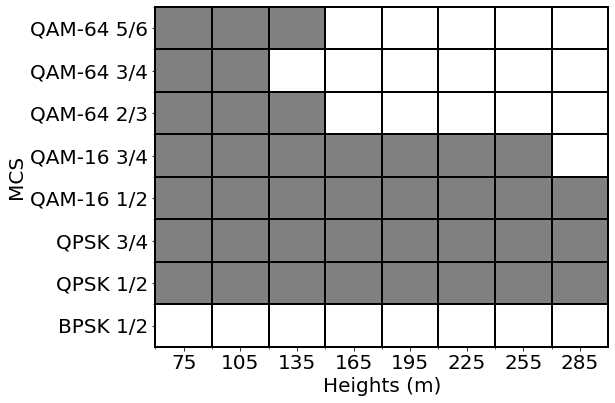

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import glob, os

""" Eligible heights for each bitrate (MCS) """
# # Reliability level = 90%
# test_cases = {
#     6.5: [75, 105, 135, 165, 195, 225, 255, 285],
#     13: [75, 105, 135, 165, 195, 225, 255, 285],
#     19.5: [75, 105, 135, 165, 195, 225, 255, 285],
#     26: [75, 105, 135, 165, 195, 225, 255, 285],
#     39: [75, 105, 135, 165, 195, 225, 255, 285],
#     52: [75, 105, 135, 165],
#     58.5: [75, 105, 135,],
#     65: [75, 105, 135, 165]
# }

# # Reliability level = 99%
# test_cases = {
#     6.5: [],
#     13: [75, 105, 135, 165, 195, 225, 255, 285],
#     19.5: [75, 105, 135, 165, 195, 225, 255, 285],
#     26: [75, 105, 135, 165, 195, 225, 255, 285],
#     39: [75, 105, 135, 165, 195, 225, 255],
#     52: [75, 105, 135],
#     58.5: [75, 105, 135,],
#     65: [75, 105, 135]
# }

# Reliability level = 99.9%
test_cases = {
    6.5: [],
    13: [75, 105, 135, 165, 195, 225, 255, 285],
    19.5: [75, 105, 135, 165, 195, 225, 255, 285],
    26: [75, 105, 135, 165, 195, 225, 255, 285],
    39: [75, 105, 135, 165, 195, 225, 255],
    52: [75, 105, 135],
    58.5: [75, 105],
    65: [75, 105, 135]
}

all_heights = [75, 105, 135, 165, 195, 225, 255, 285]
heatmap = np.zeros((len(test_cases), len(all_heights)), dtype=int)

i = 0
for bitrate, heights in test_cases.items():
    j = 0
    for height in all_heights:
        if height in heights:
            heatmap[i, j] = 1
        j += 1
    i += 1

mcs = ["BPSK 1/2", "QPSK 1/2", "QPSK 3/4", "QAM-16 1/2", "QAM-16 3/4","QAM-64 2/3", "QAM-64 3/4", "QAM-64 5/6"]
mcs = list(np.flip(mcs)) 
# Create a colormap
cmap = mcolors.ListedColormap(['white', 'gray'])

plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(20, 6))
im = ax.imshow(np.flipud(heatmap), vmin=0, vmax=1, cmap=cmap, aspect=0.75)

ax.set_xticks(range(len(all_heights)), labels=all_heights, fontsize=20)
ax.set_yticks(range(len(mcs)), labels=mcs, fontsize=20)
ax.set_xlabel("Heights (m)")
ax.set_ylabel("MCS")
ax.set_xticks(np.arange(len(all_heights))-.5, minor=True)
ax.set_yticks(np.arange(len(mcs))-.5, minor=True)
ax.grid(which="minor", color="k", linestyle='-', linewidth=2)
[x.set_linewidth(2) for x in ax.spines.values()]

# cbar = ax.figure.colorbar(im, ax=ax, ticks=[20, 40, 60, 80], pad=0.02)
# cbar.ax.set_yticklabels(['20%', '40%', '60%', '80%']) 
# cbar.ax.set_ylabel("Interference Strength (Reliability Range)", rotation=-90, va='bottom')
fig.tight_layout()
